In [1]:
!unzip "/content/drive/MyDrive/Ai Palmistry project/Tarot/archive (1).zip" -d "/content/tarot_dataset"

Archive:  /content/drive/MyDrive/Ai Palmistry project/Tarot/archive (1).zip
  inflating: /content/tarot_dataset/cards/c01.jpg  
  inflating: /content/tarot_dataset/cards/c02.jpg  
  inflating: /content/tarot_dataset/cards/c03.jpg  
  inflating: /content/tarot_dataset/cards/c04.jpg  
  inflating: /content/tarot_dataset/cards/c05.jpg  
  inflating: /content/tarot_dataset/cards/c06.jpg  
  inflating: /content/tarot_dataset/cards/c07.jpg  
  inflating: /content/tarot_dataset/cards/c08.jpg  
  inflating: /content/tarot_dataset/cards/c09.jpg  
  inflating: /content/tarot_dataset/cards/c10.jpg  
  inflating: /content/tarot_dataset/cards/c11.jpg  
  inflating: /content/tarot_dataset/cards/c12.jpg  
  inflating: /content/tarot_dataset/cards/c13.jpg  
  inflating: /content/tarot_dataset/cards/c14.jpg  
  inflating: /content/tarot_dataset/cards/m00.jpg  
  inflating: /content/tarot_dataset/cards/m01.jpg  
  inflating: /content/tarot_dataset/cards/m02.jpg  
  inflating: /content/tarot_dataset/card

In [2]:
!ls /content/tarot_dataset

cards  tarot-images.json


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

from PIL import Image

In [4]:
with open("/content/tarot_dataset/tarot-images.json", "r") as f:
    tarot_data = json.load(f)

type(tarot_data)

dict

In [5]:
tarot_data.keys()

dict_keys(['description', 'cards'])

In [6]:
df = pd.DataFrame(tarot_data["cards"])

In [7]:
df.head()

,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

In [9]:
df.describe(include="all")

,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
count,78,78,78,78,78,78,78,78,22,22,62,38,22,78,40,56
unique,78,22,2,5,78,78,78,78,22,22,33,38,22,78,40,56
top,The Fool,1,Minor Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,"4 (The Status Quo: stability, equality, persis...",Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"Cancer, Scorpio, Pisces","""I listen to the counsel of my heart."""
freq,1,5,56,22,1,1,1,1,1,1,4,1,1,1,1,1


In [10]:
df.isnull().sum()

,0
name,0
number,0
arcana,0
suit,0
img,0
fortune_telling,0
keywords,0
meanings,0
Archetype,56
Hebrew Alphabet,56


## Missing Value Analysis

The core columns required for tarot card recognition (`name`, `arcana`, `suit`, `img`, `keywords`, `meanings`) contain **no missing values**.

Some descriptive metadata columns such as **Archetype, Hebrew Alphabet, Astrology, Elemental,** and **Affirmation** contain missing values. These are supplementary attributes and do not affect the image classification task.

In [12]:
df[["name", "number", "arcana", "suit", "img"]].duplicated().sum()

np.int64(0)

No duplicate records were found among the core card attributes (name, number, arcana, suit, img).

In [13]:
df["arcana"].value_counts()

,count
arcana,
Minor Arcana,56
Major Arcana,22


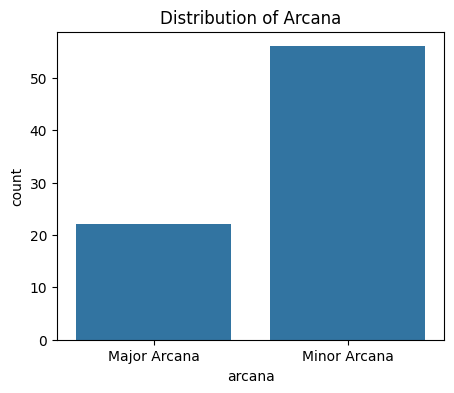

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="arcana")
plt.title("Distribution of Arcana")
plt.show()

In [15]:
df["suit"].value_counts()

,count
suit,
Trump,22
Cups,14
Swords,14
Wands,14
Pentacles,14


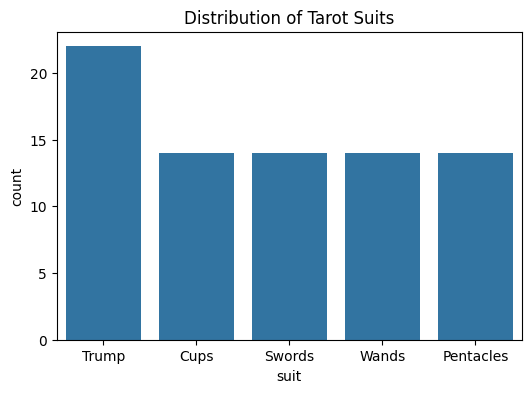

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="suit", order=df["suit"].value_counts().index)
plt.title("Distribution of Tarot Suits")
plt.show()

The deck contains 22 Trump (Major Arcana) cards and 14 cards each from the four Minor Arcana suits: Cups, Pentacles, Swords, and Wands. This confirms that the dataset represents a complete standard tarot deck.

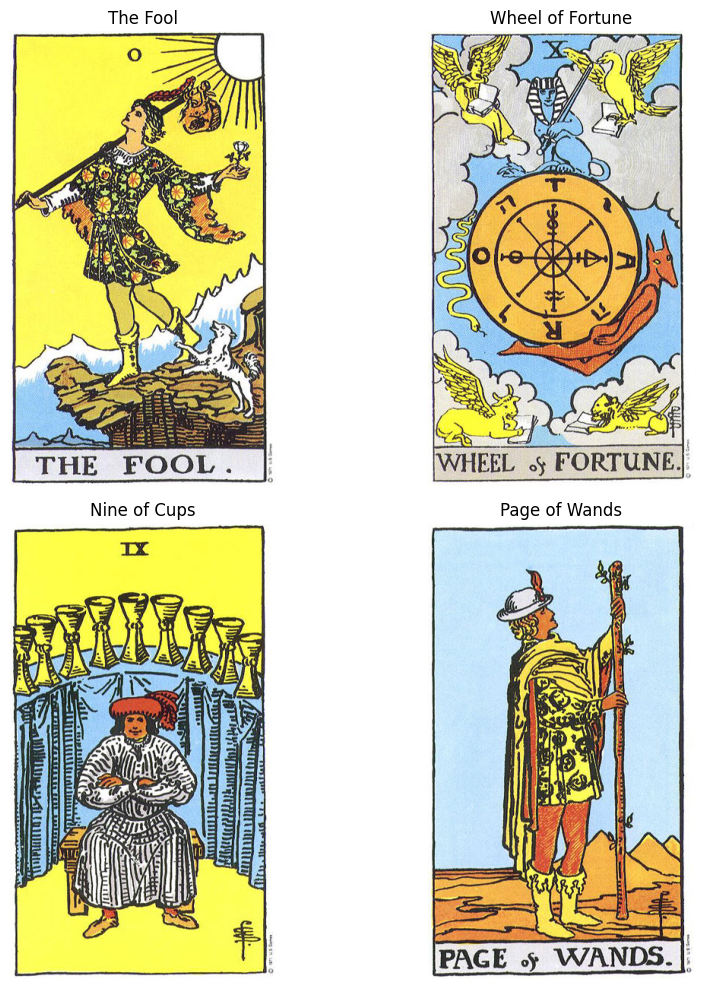

In [18]:
sample_cards = df.iloc[[0, 10, 30, 60]]

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_cards.iterrows()):
    img = Image.open(f"/content/tarot_dataset/cards/{row['img']}")

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(row["name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
img = Image.open("/content/tarot_dataset/cards/" + df.iloc[0]["img"])

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (350, 600)
Image Mode: RGB


In [20]:
import numpy as np

img_array = np.array(img)

print("Array Shape:", img_array.shape)
print("Minimum Pixel Value:", img_array.min())
print("Maximum Pixel Value:", img_array.max())

Array Shape: (600, 350, 3)
Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [21]:
from PIL import Image
import os

sizes = []

image_folder = "/content/tarot_dataset/cards/"

for img_name in df["img"]:
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

unique_sizes = set(sizes)

print("Number of unique image sizes:", len(unique_sizes))
print("Different sizes:", unique_sizes)

Number of unique image sizes: 1
Different sizes: {(350, 600)}


All Tarot card images have a consistent resolution of 350×600 pixels, making the dataset suitable for preprocessing and deep learning model training.

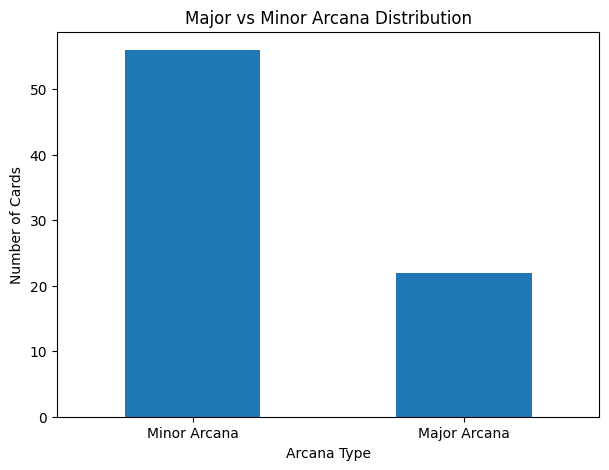

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

df["arcana"].value_counts().plot(kind="bar")

plt.title("Major vs Minor Arcana Distribution")
plt.xlabel("Arcana Type")
plt.ylabel("Number of Cards")
plt.xticks(rotation=0)

plt.show()

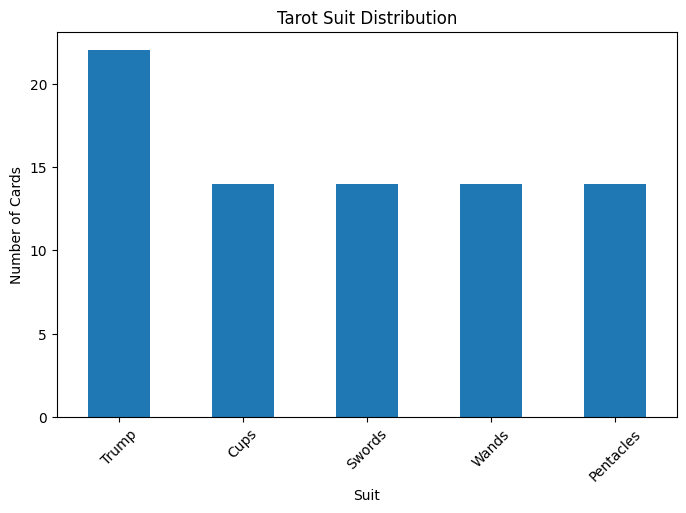

In [28]:
plt.figure(figsize=(8,5))

df["suit"].value_counts().plot(kind="bar")

plt.title("Tarot Suit Distribution")
plt.xlabel("Suit")
plt.ylabel("Number of Cards")
plt.xticks(rotation=45)

plt.show()

## Key Insights

- The dataset contains a total of 78 Tarot cards, consisting of 22 Major Arcana cards and 56 Minor Arcana cards.
- The Minor Arcana category is further divided equally into four suits: Cups, Swords, Wands, and Pentacles, with 14 cards each.
- All images are stored in RGB format with pixel values ranging from 0 to 255, making them suitable for deep learning-based image processing.
- The images have a consistent resolution of 350 × 600 pixels, which simplifies preprocessing before model training.
- No significant imbalance exists among Minor Arcana suits, as each suit contains an equal number of cards.
- The dataset contains additional semantic information such as meanings, keywords, astrology, numerology, and spiritual interpretations, which can support AI-based Tarot interpretation.

## Project Relevance

The Tarot dataset is highly relevant for developing an AI-powered Tarot Intelligence Platform.

The image data enables the development of a computer vision model capable of recognizing Tarot cards from uploaded images.

The additional metadata such as card meanings, keywords, fortune telling descriptions, and symbolic attributes can be used to generate intelligent interpretations after card identification.

This combination of Computer Vision and Natural Language Processing can help build an interactive AI system that provides automated Tarot card analysis.

## Conclusion

Exploratory Data Analysis was performed on the Tarot card dataset to understand its structure, quality, and suitability for machine learning applications.

The analysis confirmed that the dataset contains properly formatted RGB images with consistent dimensions and balanced class distribution.

The availability of both visual features and detailed textual metadata makes this dataset suitable for building a multimodal AI-based Tarot Intelligence Platform using deep learning and NLP techniques.